In [11]:
import numpy as np
import matplotlib.pyplot as plt
import dragonfly
import h5py
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
import matplotlib.patches as patches


In [12]:
plt.close('all')


In [13]:
df_tag = 'newmask_cp256rb1_0001'
output_n = 'output_030.h5'


with h5py.File(f'./{df_tag}/data/{output_n}','r') as f:
    intens1 = f['/intens'][...]
intens1 = intens1.squeeze()




In [16]:
%matplotlib inline
det = dragonfly.Detector(fname=f'./{df_tag}/data/det.h5')

#qmax is in voxel units
q = np.linspace(-det.qmax(), det.qmax(), int(np.ceil(2*det.qmax())+3))

qx,qy,qz = np.meshgrid(q,q,q,)

qq = np.sqrt(qx**2 + qy**2 + qz**2)

#pixel_size_mm = 0.2
##det_z_mm = 86.9
#det_z_mm = 214
#lamb_a = 1.26
#dq = (2*np.pi*pixel_size_mm)/(lamb_a*det_z_mm)

lamb_a = 1.26
ewald_rad = 1070

dq = 1/(lamb_a*ewald_rad) 
qq = qq*dq

intens_crop = np.zeros(intens1.shape)

intens_crop[:] = intens1
#intens_crop[qq>0.50*qq.max()] = 0





def plot_slice(i, target_q):
    fig, ax = plt.subplots(1,2, figsize=(6,12), dpi=200)
    ax[0].imshow(intens_crop[i], clim=(0,1e-1))
    ax[1].imshow(intens_crop[i], clim=(0,intens_crop.max()))

    #target_q = 1.5  # Replace with your desired q value
    cs = ax[0].contour(
    qq[i],
    levels=[target_q],
    colors="red",
    linewidths=0.5,
    linestyles="dashed",
    )
    
    
    plt.title(f'x={i}')
    plt.show()
    plt.close(fig)
        
        
from ipywidgets import interact, IntSlider, FloatSlider
interact(
    plot_slice, 
    i=IntSlider(min=0, max=intens_crop.shape[0] - 1, step=1, value=180, description='Slice:'),
    target_q = FloatSlider(min=0, max=0.50*qq.max(), step=0.005, description='q')
)

interactive(children=(IntSlider(value=180, description='Slice:', max=360), FloatSlider(value=0.0, description=…

<function __main__.plot_slice(i, target_q)>

array([[ 13, 283, 358],
       [ 14, 306, 241],
       [ 14, 288, 240],
       ...,
       [580, 288, 353],
       [580, 306, 354],
       [581, 311, 236]], shape=(5152, 3))

In [47]:
from scipy.spatial.distance import pdist, squareform

def find_6fold_groups_arbitrary(coords, center, tolerance=5):
    """
    Groups points into 6-fold orbits regardless of plane orientation.
    Identifies 6 points that lie at equal radial distances from center
    and form a planar regular hexagon.
    """
    unassigned = set(range(len(coords)))
    groups = []
    
    # Pre-calculate relative vectors and radial distances from center
    vecs = coords - center
    radii = np.linalg.norm(vecs, axis=1)
    
    while unassigned:
        seed_idx = unassigned.pop()
        seed_r = radii[seed_idx]
        seed_vec = vecs[seed_idx]
        
        # Candidates must have similar radial distance from origin
        candidate_indices = [
            i for i in unassigned 
            if abs(radii[i] - seed_r) < tolerance
        ]
        
        # Check all candidate pairs to find the normal vector (rotation axis)
        # The 6-fold axis u is orthogonal to the seed vector
        # Test candidate vectors to find one ~60° or ~120° away from seed
        matched_group = [seed_idx]
        
        for cand_idx in candidate_indices:
            cand_vec = vecs[cand_idx]
            # Compute angle between vectors
            cos_theta = np.dot(seed_vec, cand_vec) / (seed_r * radii[cand_idx])
            cos_theta = np.clip(cos_theta, -1.0, 1.0)
            angle_deg = np.degrees(np.arccos(cos_theta))
            
            # 6-fold symmetry angles are 60°, 120°, 180°
            if any(abs(angle_deg - target) < 5.0 for target in [60, 120, 180]):
                matched_group.append(cand_idx)
                
        # If we successfully isolated a 6-peak orbit (or partial group)
        if len(matched_group) > 1:
            for idx in matched_group[1:]:
                unassigned.remove(idx)
            groups.append(matched_group)
        else:
            groups.append([seed_idx])
            
    return groups

groups = find_6fold_groups_arbitrary(coordinates, [171,171,171], tolerance=2)

print(groups)

[[0, 13, 14, 15, 16, 48, 50, 51, 52, 65], [1, 9, 10, 19, 45, 55, 56, 64], [2, 7, 8, 28, 37, 57, 58, 63], [3, 5, 27, 38, 60, 61], [4, 6, 22, 43, 59, 62], [11, 20, 44, 54], [12, 18, 21, 46, 47, 53], [17, 49], [23, 24, 41, 42], [25, 40], [26, 39], [29, 31], [30, 36], [32, 33], [34, 35]]


In [48]:
# Color palette setup

cmap = plt.get_cmap('tab20')
group_colors = [cmap((i % 20) / 20.0) for i in range(len(groups))]

# Pre-compute sphere geometry mesh
RADIUS = 4.0
GRID_SIZE = 343
CENTER=[171,171,171]
u, v = np.linspace(0, 2 * np.pi, 15), np.linspace(0, np.pi, 15)
unit_x = np.outer(np.cos(u), np.sin(v))
unit_y = np.outer(np.sin(u), np.sin(v))
unit_z = np.outer(np.ones(np.size(u)), np.cos(v))

def sort_ring_3d(pts, center):
    """Sorts coplanar 3D vertices around center for clean loop plotting."""
    # Convert vectors to float to allow division/norm operations
    vecs = (pts - center).astype(np.float64)
    
    if len(pts) < 3:
        return pts
        
    normal = np.cross(vecs[0], vecs[1])
    if np.linalg.norm(normal) == 0:
        normal = np.cross(vecs[0], vecs[2])
        
    # Floating-point in-place division now works safely!
    normal /= np.linalg.norm(normal)
    
    u_vec = vecs[0] / np.linalg.norm(vecs[0])
    v_vec = np.cross(normal, u_vec)
    angles = np.arctan2(np.dot(vecs, v_vec), np.dot(vecs, u_vec))
    
    return pts[np.argsort(angles)]

# -------------------------------------------------------------------------
# The requested `draw()` Function
# -------------------------------------------------------------------------
def draw(target_group_ids):
    """
    Renders 3D peak groups using 1-based group IDs.
    
    Parameters:
        target_group_ids (list of int): List of group IDs to visualize.
                                        e.g., [1, 2, 3]
    """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    fig.patch.set_facecolor('#111116')
    
    ax.set_xlim([0, GRID_SIZE])
    ax.set_ylim([0, GRID_SIZE])
    ax.set_zlim([0, GRID_SIZE])
    ax.set_box_aspect([1, 1, 1])
    ax.set_facecolor('#111116')
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    ax.xaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.yaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.zaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.tick_params(colors='white')
    ax.set_xlabel('X', color='white')
    ax.set_ylabel('Y', color='white')
    ax.set_zlabel('Z', color='white')
    
    total_peaks = 0
    # Convert 1-based user input [1, 2, 3] to 0-based list indices [0, 1, 2]
    zero_indexed_ids = [g_id - 1 for g_id in target_group_ids if 0 < g_id <= len(groups)]
    
    for g_i in zero_indexed_ids:
        color = group_colors[g_i]
        indices = groups[g_i]
        total_peaks += len(indices)
        
        # Plot individual peak spheres
        for idx in indices:
            cx, cy, cz = coords[idx]
            ax.plot_surface(
                cx + RADIUS * unit_x,
                cy + RADIUS * unit_y,
                cz + RADIUS * unit_z,
                color=color, alpha=0.7, linewidth=0, antialiased=True
            )
            
        # Draw dotted connections if 3 or more coplanar peaks belong to the orbit
        if len(indices) >= 3:
            sorted_pts = sort_ring_3d(coords[indices], CENTER)
            loop_pts = np.vstack([sorted_pts, sorted_pts[0]])
            ax.plot(
                loop_pts[:, 0], loop_pts[:, 1], loop_pts[:, 2], 
                color=color, linestyle='--', linewidth=1.5, alpha=0.8
            )
            
    # Set descriptive window title
    group_str = ", ".join([str(g) for g in target_group_ids])
    ax.set_title(f"Groups: [{group_str}] ({total_peaks} total peaks)", color='white')
    
    plt.show()

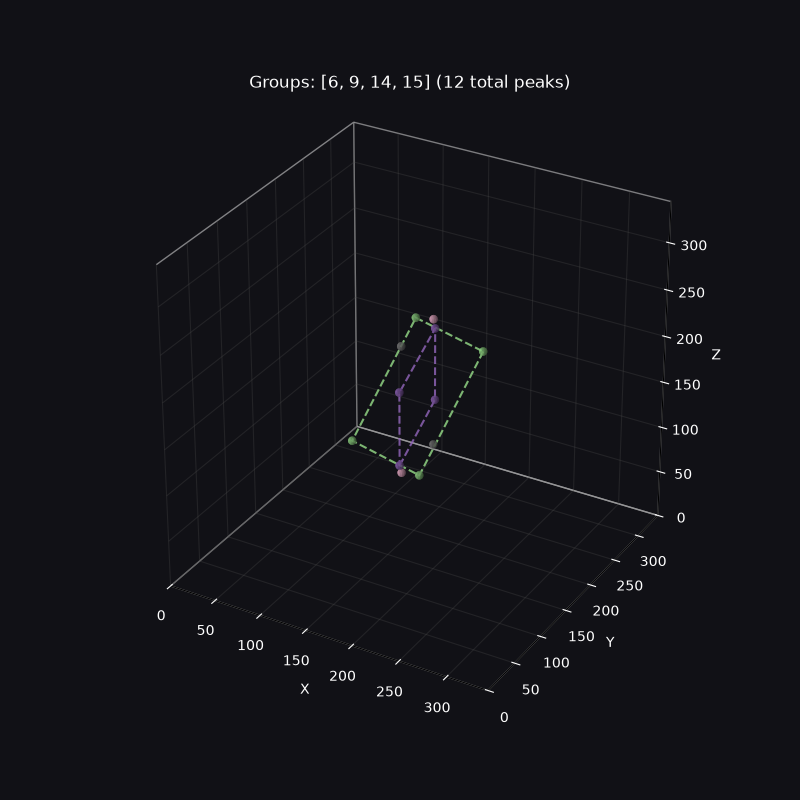

[11, 20, 44, 54]
11 [125 128 131]
20 [146 211 229]
44 [196 131 113]
54 [217 214 211]
[23, 24, 41, 42]
23 [155 232 132]
24 [155 232 210]
41 [187 110 132]
42 [187 110 210]
[32, 33]
32 [171 141 103]
33 [171 201 239]
[34, 35]
34 [171 141 239]
35 [171 201 103]


In [106]:
%matplotlib widget
#draw([4,6,])
#draw([i for i in range(len(groups))])

draw([6,9, 14,15])
#draw([11,12,13,15])

for i in [5,8,13,14]:
    print(groups[i])
    for peak in groups[i]:
        print(peak, coords[peak])


In [ ]:
assert False

In [ ]:
# -------------------------------------------------------------------------
# 3. Setup Colors & Visual Geometry
# -------------------------------------------------------------------------
from matplotlib.widgets import Slider, Button
cmap = plt.get_cmap('tab20')
group_colors = [cmap((i % 20) / 20.0) for i in range(len(groups))]
coords = coordinates[:]
CENTER = [171,171,171]

# Sphere parametric mesh
RADIUS = 4.0
u, v = np.linspace(0, 2 * np.pi, 15), np.linspace(0, np.pi, 15)
unit_x = np.outer(np.cos(u), np.sin(v))
unit_y = np.outer(np.sin(u), np.sin(v))
unit_z = np.outer(np.ones(np.size(u)), np.cos(v))

GRID_SIZE = 343

# Helper to order 3D ring vertices cleanly for dashed lines regardless of tilt plane
def sort_ring_3d(pts, center):
    vecs = pts - center
    # Normal to plane defined by first two points
    if len(pts) < 3:
        return pts
    normal = np.cross(vecs[0], vecs[1])
    if np.linalg.norm(normal) == 0:
        normal = np.cross(vecs[0], vecs[2])
    normal /= np.linalg.norm(normal)
    
    # 2D projection angles onto plane basis (u_vec, v_vec)
    u_vec = vecs[0] / np.linalg.norm(vecs[0])
    v_vec = np.cross(normal, u_vec)
    
    angles = np.arctan2(np.dot(vecs, v_vec), np.dot(vecs, u_vec))
    return pts[np.argsort(angles)]

# -------------------------------------------------------------------------
# 4. Interactive Matplotlib Setup
# -------------------------------------------------------------------------
fig = plt.figure(figsize=(9, 8))
ax = fig.add_axes([0.1, 0.2, 0.8, 0.75], projection='3d')
fig.patch.set_facecolor('#111116')

def draw_group(group_idx):
    ax.clear()
    
    ax.set_xlim([0, GRID_SIZE])
    ax.set_ylim([0, GRID_SIZE])
    ax.set_zlim([0, GRID_SIZE])
    ax.set_box_aspect([1, 1, 1])
    ax.set_facecolor('#111116')
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    ax.xaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.yaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.zaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.tick_params(colors='white')
    
    # -1 means render ALL groups
    target_groups = range(len(groups)) if group_idx == -1 else [group_idx]
    
    for g_i in target_groups:
        color = group_colors[g_i]
        indices = groups[g_i]
        
        # Draw 3D Spheres
        for idx in indices:
            cx, cy, cz = coords[idx]
            ax.plot_surface(
                cx + RADIUS * unit_x,
                cy + RADIUS * unit_y,
                cz + RADIUS * unit_z,
                color=color, alpha=0.7, linewidth=0, antialiased=True
            )
            
        # Draw dotted lines connecting rings when viewing individual groups
        if group_idx != -1 and len(indices) > 2:
            sorted_pts = sort_ring_3d(coords[indices], CENTER)
            loop_pts = np.vstack([sorted_pts, sorted_pts[0]])
            ax.plot(
                loop_pts[:, 0], loop_pts[:, 1], loop_pts[:, 2], 
                color=color, linestyle='--', linewidth=1.5, alpha=0.8
            )

    # Title Status
    if group_idx == -1:
        ax.set_title(f"Showing ALL Groups ({len(groups)} total orbits)", color='white')
    else:
        num_peaks = len(groups[group_idx])
        ax.set_title(f"Group {group_idx + 1} of {len(groups)} ({num_peaks} peaks)", color='white')
        
    fig.canvas.draw_idle()

# -------------------------------------------------------------------------
# 5. Add UI Controls
# -------------------------------------------------------------------------
ax_slider = fig.add_axes([0.2, 0.08, 0.5, 0.03], facecolor='#222228')
slider = Slider(
    ax=ax_slider,
    label='Group ID ',
    valmin=1,
    valmax=len(groups),
    valinit=1,
    valstep=1,
    color='#ff4b4b'
)
slider.label.set_color('white')
slider.valtext.set_color('white')

ax_button = fig.add_axes([0.75, 0.075, 0.15, 0.04])
button_all = Button(ax_button, 'Show All', color='#33333d', hovercolor='#555566')
button_all.label.set_color('white')

def update(val):
    draw_group(int(slider.val) - 1)

def show_all(event):
    draw_group(-1)

slider.on_changed(update)
button_all.on_clicked(show_all)

# Initial Render
draw_group(0)
plt.show()

In [ ]:
# Enables interactive pan/zoom/rotate widgets
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RangeSlider, Button

# --- Assumes `coords`, `CENTER`, and `groups` are defined using find_6fold_groups_arbitrary ---

# Setup Colors & Mesh as before
cmap = plt.get_cmap('tab20')
group_colors = [cmap((i % 20) / 20.0) for i in range(len(groups))]

RADIUS = 4.0
u, v = np.linspace(0, 2 * np.pi, 15), np.linspace(0, np.pi, 15)
unit_x = np.outer(np.cos(u), np.sin(v))
unit_y = np.outer(np.sin(u), np.sin(v))
unit_z = np.outer(np.ones(np.size(u)), np.cos(v))

GRID_SIZE = 343

def sort_ring_3d(pts, center):
    vecs = pts - center
    if len(pts) < 3:
        return pts
    normal = np.cross(vecs[0], vecs[1])
    if np.linalg.norm(normal) == 0:
        normal = np.cross(vecs[0], vecs[2])
    normal /= np.linalg.norm(normal)
    
    u_vec = vecs[0] / np.linalg.norm(vecs[0])
    v_vec = np.cross(normal, u_vec)
    angles = np.arctan2(np.dot(vecs, v_vec), np.dot(vecs, u_vec))
    return pts[np.argsort(angles)]

# --- Plotting Setup ---
fig = plt.figure(figsize=(9, 8))
ax = fig.add_axes([0.1, 0.22, 0.8, 0.73], projection='3d')
fig.patch.set_facecolor('#111116')

def draw_selected_groups(group_indices):
    ax.clear()
    
    ax.set_xlim([0, GRID_SIZE])
    ax.set_ylim([0, GRID_SIZE])
    ax.set_zlim([0, GRID_SIZE])
    ax.set_box_aspect([1, 1, 1])
    ax.set_facecolor('#111116')
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    ax.xaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.yaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.zaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.tick_params(colors='white')
    
    total_peaks = 0
    for g_i in group_indices:
        color = group_colors[g_i]
        indices = groups[g_i]
        total_peaks += len(indices)
        
        # Plot spheres
        for idx in indices:
            cx, cy, cz = coords[idx]
            ax.plot_surface(
                cx + RADIUS * unit_x,
                cy + RADIUS * unit_y,
                cz + RADIUS * unit_z,
                color=color, alpha=0.7, linewidth=0, antialiased=True
            )
            
        # Plot connecting ring outline if subset is active
        if len(indices) > 2:
            sorted_pts = sort_ring_3d(coords[indices], CENTER)
            loop_pts = np.vstack([sorted_pts, sorted_pts[0]])
            ax.plot(
                loop_pts[:, 0], loop_pts[:, 1], loop_pts[:, 2], 
                color=color, linestyle='--', linewidth=1.5, alpha=0.8
            )

    # Dynamic Title
    if len(group_indices) == len(groups):
        ax.set_title(f"Showing ALL Groups ({len(groups)} total orbits)", color='white')
    elif len(group_indices) == 1:
        g = group_indices[0]
        ax.set_title(f"Group {g + 1} of {len(groups)} ({len(groups[g])} peaks)", color='white')
    else:
        min_g, max_g = group_indices[0] + 1, group_indices[-1] + 1
        ax.set_title(f"Groups {min_g} to {max_g} ({len(group_indices)} groups, {total_peaks} peaks)", color='white')
        
    fig.canvas.draw_idle()

# --- Range Slider Control ---
ax_slider = fig.add_axes([0.2, 0.08, 0.5, 0.03], facecolor='#222228')
range_slider = RangeSlider(
    ax=ax_slider,
    label='Group Range ',
    valmin=1,
    valmax=len(groups),
    valinit=(1, 3),  # Initial range: Groups 1 to 3
    valstep=1,
    color='#ff4b4b'
)
range_slider.label.set_color('white')
range_slider.valtext.set_color('white')

# Show All Button
ax_button = fig.add_axes([0.75, 0.075, 0.15, 0.04])
button_all = Button(ax_button, 'Show All', color='#33333d', hovercolor='#555566')
button_all.label.set_color('white')

# Event Listeners
def update(val):
    min_idx = int(range_slider.val[0]) - 1
    max_idx = int(range_slider.val[1])
    draw_selected_groups(list(range(min_idx, max_idx)))

def show_all(event):
    range_slider.set_val((1, len(groups)))
    draw_selected_groups(list(range(len(groups))))

range_slider.on_changed(update)
button_all.on_clicked(show_all)

# Initial draw
draw_selected_groups([0,1,2,11,12,14,16])
plt.show()



In [ ]:
# Enables interactive pan/zoom/rotate widgets
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# -------------------------------------------------------------------------
# 1. Coordinates Data & 6-Fold Grouping
# -------------------------------------------------------------------------
coords = coordinates[:]

CENTER = np.array([171.0, 171.0, 171.0])
TOLERANCE = 20

def rotate_z(point, center, angle_rad):
    p_centered = point - center
    cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
    rot_matrix = np.array([[cos_a, -sin_a, 0], [sin_a, cos_a, 0], [0, 0, 1]])
    return center + rot_matrix @ p_centered

groups = []
unassigned = set(range(len(coords)))
angles = [np.radians(k * 60) for k in range(6)]

while unassigned:
    seed_idx = unassigned.pop()
    seed_point = coords[seed_idx]
    current_group = [seed_idx]
    
    for angle in angles[1:]:
        expected_partner = rotate_z(seed_point, CENTER, angle)
        best_match_idx, best_dist = None, float('inf')
        for other_idx in unassigned:
            dist = np.linalg.norm(coords[other_idx] - expected_partner)
            if dist < TOLERANCE and dist < best_dist:
                best_dist, best_match_idx = dist, other_idx
        if best_match_idx is not None:
            current_group.append(best_match_idx)
            unassigned.remove(best_match_idx)
            
    groups.append(current_group)

# Color Map setup
cmap = plt.get_cmap('tab20')
group_colors = [cmap((i % 20) / 20.0) for i in range(len(groups))]

# Parametric Sphere mesh
RADIUS = 4.0
u, v = np.linspace(0, 2*np.pi, 15), np.linspace(0, np.pi, 15)
unit_x = np.outer(np.cos(u), np.sin(v))
unit_y = np.outer(np.sin(u), np.sin(v))
unit_z = np.outer(np.ones(np.size(u)), np.cos(v))

# -------------------------------------------------------------------------
# 2. Interactive Setup
# -------------------------------------------------------------------------
fig = plt.figure(figsize=(9, 8))
ax = fig.add_axes([0.1, 0.2, 0.8, 0.75], projection='3d')

GRID_SIZE = 343

def draw_group(group_idx):
    ax.clear()
    
    # Grid & Limits setup
    ax.set_xlim([0, GRID_SIZE])
    ax.set_ylim([0, GRID_SIZE])
    ax.set_zlim([0, GRID_SIZE])
    ax.set_box_aspect([1, 1, 1])
    ax.set_facecolor('#111116')
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    ax.xaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.yaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.zaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
    ax.tick_params(colors='white')
    
    # Determine which groups to draw (-1 = ALL)
    target_groups = range(len(groups)) if group_idx == -1 else [group_idx]
    
    for g_i in target_groups:
        color = group_colors[g_i]
        indices = groups[g_i]
        
        # Plot individual spheres
        for idx in indices:
            cx, cy, cz = coords[idx]
            ax.plot_surface(
                cx + RADIUS * unit_x,
                cy + RADIUS * unit_y,
                cz + RADIUS * unit_z,
                color=color, alpha=0.7, linewidth=0, antialiased=True
            )
            
        # Draw dotted connecting line between symmetry members if single group view
        if group_idx != -1 and len(indices) > 1:
            pts = coords[indices]
            # Sort radially around Z axis for clean ring lines
            angles_arr = np.arctan2(pts[:,1]-CENTER[1], pts[:,0]-CENTER[0])
            sorted_pts = pts[np.argsort(angles_arr)]
            # Close the loop
            loop_pts = np.vstack([sorted_pts, sorted_pts[0]])
            ax.plot(loop_pts[:,0], loop_pts[:,1], loop_pts[:,2], 
                    color=color, linestyle='--', linewidth=1.5, alpha=0.8)

    # Dynamic Title
    if group_idx == -1:
        ax.set_title(f"Showing ALL Groups ({len(groups)} total)", color='white')
    else:
        num_peaks = len(groups[group_idx])
        ax.set_title(f"Group {group_idx + 1} of {len(groups)} ({num_peaks} peaks)", color='white')
        
    fig.canvas.draw_idle()

# -------------------------------------------------------------------------
# 3. Add UI Widgets (Slider + Toggle Button)
# -------------------------------------------------------------------------
fig.patch.set_facecolor('#111116')

# Slider for choosing specific group index
ax_slider = fig.add_axes([0.2, 0.08, 0.5, 0.03], facecolor='#222228')
slider = Slider(
    ax=ax_slider,
    label='Group ID ',
    valmin=1,
    valmax=len(groups),
    valinit=1,
    valstep=1,
    color='#ff4b4b'
)
slider.label.set_color('white')
slider.valtext.set_color('white')

# Button to view ALL groups at once
ax_button = fig.add_axes([0.75, 0.075, 0.15, 0.04])
button_all = Button(ax_button, 'Show All', color='#33333d', hovercolor='#555566')
button_all.label.set_color('white')

# Event Listeners
def update(val):
    draw_group(int(slider.val) - 1)

def show_all(event):
    draw_group(-1)

slider.on_changed(update)
button_all.on_clicked(show_all)

# Initial draw
draw_group(0)
plt.show()

In [ ]:
%matplotlib widget  

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

coords = coordinates[:]

CENTER = np.array([171.0, 171.0, 171.0])
TOLERANCE = 3.5  # Max voxel distance tolerance for floating point rounding

# 2. Function to rotate point around Z-axis passing through CENTER by theta radians
def rotate_z(point, center, angle_rad):
    # Shift to center
    p_centered = point - center
    # 2D Rotation matrix in XY plane
    cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
    rot_matrix = np.array([
        [cos_a, -sin_a, 0],
        [sin_a,  cos_a, 0],
        [0,      0,     1]
    ])
    return center + rot_matrix @ p_centered

# 3. Group Coordinates by 6-fold Symmetry
groups = []
unassigned = set(range(len(coords)))

# Angles for 6-fold symmetry: 0°, 60°, 120°, 180°, 240°, 300°
angles = [np.radians(k * 60) for k in range(6)]

while unassigned:
    seed_idx = unassigned.pop()
    seed_point = coords[seed_idx]
    
    current_group = [seed_idx]
    
    # Generate all 6 expected symmetric partners
    for angle in angles[1:]:
        expected_partner = rotate_z(seed_point, CENTER, angle)
        
        # Check if any remaining point is close to the expected position
        best_match_idx = None
        best_dist = float('inf')
        
        for other_idx in unassigned:
            dist = np.linalg.norm(coords[other_idx] - expected_partner)
            if dist < TOLERANCE and dist < best_dist:
                best_dist = dist
                best_match_idx = other_idx
                
        if best_match_idx is not None:
            current_group.append(best_match_idx)
            unassigned.remove(best_match_idx)
            
    groups.append(current_group)

# 4. Color Assignment
cmap = plt.get_cmap('gist_rainbow')
point_colors = {}
for group_id, group in enumerate(groups):
    color = cmap((group_id % 20) / 20.0)
    for point_idx in group:
        point_colors[point_idx] = color

# 5. Plotting Interactive Spheres
GRID_SIZE = 343
RADIUS = 4.0
ALPHA = 0.6

u = np.linspace(0, 2 * np.pi, 15)
v = np.linspace(0, np.pi, 15)
unit_x = np.outer(np.cos(u), np.sin(v))
unit_y = np.outer(np.sin(u), np.sin(v))
unit_z = np.outer(np.ones(np.size(u)), np.cos(v))

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for idx, point in enumerate(coords):
    cx, cy, cz = point
    color = point_colors[idx]
    
    x_sphere = cx + RADIUS * unit_x
    y_sphere = cy + RADIUS * unit_y
    z_sphere = cz + RADIUS * unit_z

    ax.plot_surface(
        x_sphere, y_sphere, z_sphere,
        color=color, alpha=ALPHA, linewidth=0, antialiased=True
    )

# Formatting
ax.set_xlim([0, GRID_SIZE])
ax.set_ylim([0, GRID_SIZE])
ax.set_zlim([0, GRID_SIZE])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'6-Fold Symmetric Groups ({len(groups)} distinct orbits)', color='white')

ax.set_box_aspect([1, 1, 1])
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
ax.yaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
ax.zaxis._axinfo['grid']['color'] = (0.3, 0.3, 0.3, 0.3)
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.zaxis.label.set_color('white')

plt.show()

In [ ]:
vol_smooth = gaussian_filter(q_intens1,sigma=1.0)
vol_bg = gaussian_filter(q_intens1, sigma=5.0)
vol_filtered1 = vol_smooth - vol_bg



vol_smooth = gaussian_filter(q_intens2,sigma=1.0)
vol_bg = gaussian_filter(q_intens2, sigma=5.0)
vol_filtered2 = vol_smooth - vol_bg

# Finds local maxima in 3D with minimum separation distance
coordinates = peak_local_max(
    vol_filtered1, 
    min_distance=5,      # Min distance (in voxels) between detected peaks
    threshold_rel=0.05    # Threshold relative to maximum filtered intensity
)
coordinates = coordinates[coordinates[:, 0].argsort()]
#coordinates = coordinates[coordinates[:, 0]!=162]
#coordinates = coordinates[coordinates[:, 0]!=180]

coords = coordinates[:]


peak_qx_inds, peak_qy_inds, peak_qz_inds = coordinates.T

print(coordinates.shape)
print(np.unique(peak_qx_inds).shape)